In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, r2_score, mean_squared_error, log_loss

In [2]:
# load processed data
metadata = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_metadata.csv")
features = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_features.csv")

# load dataframes
df = metadata.merge(features, on="filename", how="inner")
features = features.drop(columns=["filename"])

In [3]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.mean(axis=0)[:5]
X_train_scaled.std(axis=0)[:5]

# Baseline model

classifier = LogisticRegression(max_iter=2000)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.639511201629328
Precision: 0.635139845562833
Recall: 0.6380026990553306
Macro F1: 0.6356107342023884
Log Loss 1.4252414617944464
[[50  0  3  5  6  1  6  4]
 [ 0 58  2  0  3  2 10  0]
 [ 5  2 23  0  1  2  2  4]
 [ 9  2  1 45  5  0  9  4]
 [ 8  2  1  8 46  4  5  1]
 [ 0  2  0  1  2 28  4  1]
 [ 1 14  4  7  1  5 42  1]
 [ 1  3  6  3  3  0  1 22]]


Log loss for 8 classifications would give a value around 2.079 if the model was guessing at complete random. This means the model is actually improving prediction, though not a whole lot. Preferrably this value would be closer to 0.

In [4]:
# Predicting emotional intensity from features

X = features.copy()
y = df["intensity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.mean(axis=0)[:5]
X_train_scaled.std(axis=0)[:5]

# Baseline model

classifier = LogisticRegression(max_iter=2000)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7515274949083504
Precision: 0.756438557763061
Recall: 0.7442430917100521
Macro F1: 0.7455915330252787
Log Loss 0.5159395773569019
[[222  42]
 [ 80 147]]


The model is much better at classifying intensity than emotion type! Though, this is to be expected as there are only 3 classifications.

In [5]:
# Predicting gender from features

X = features.copy()
y = df["actor_gender"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.mean(axis=0)[:5]
X_train_scaled.std(axis=0)[:5]

# baseline model

classifier = LogisticRegression(max_iter=2000)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9918533604887984
Precision: 0.9919555688384141
Recall: 0.9917759336099585
Macro F1: 0.9918492695883134
Log Loss 0.016464854502058424
[[238   3]
 [  1 249]]


The model is nearly perfect at classifying the gender of an actor!

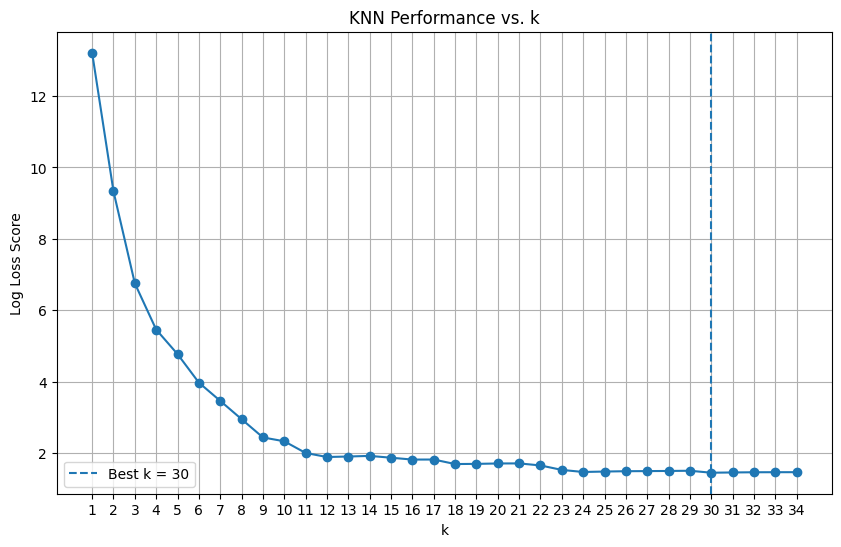

Best k: 30
Best Log Loss: 1.4537


In [6]:

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.mean(axis=0)[:5]
X_train_scaled.std(axis=0)[:5]

# Try different k values
k_values = range(1, 35)
log_loss_scores = []

for k in k_values:
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X_train_scaled, y_train)

    y_proba = classifier.predict_proba(X_test_scaled)

    log_loss_scores.append(
        log_loss(y_test, y_proba)
    )

# Find best k
best_k = k_values[log_loss_scores.index(min(log_loss_scores))]
best_log_loss = min(log_loss_scores)

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(k_values, log_loss_scores, marker="o")
plt.axvline(best_k, linestyle="--", label=f"Best k = {best_k}")

plt.xlabel("k")
plt.ylabel("Log Loss Score")
plt.title("KNN Performance vs. k")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best k: {best_k}")
print(f"Best Log Loss: {best_log_loss:.4f}")

30 is the best k value to use for this data.

In [7]:
# baseline model

classifier = KNeighborsClassifier(n_neighbors=30)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.45010183299389
Precision: 0.46904902457722636
Recall: 0.4209784075573549
Macro F1: 0.4146833909723252
Log Loss 1.4537413591583397
[[41  2  5  7 12  0  1  7]
 [ 0 58  3  1  4  0  9  0]
 [ 1  8 14  3  3  0  0 10]
 [ 9  8  3 28 12  1 12  2]
 [14 18  0  7 30  0  4  2]
 [ 0 18  3  1  2  4  9  1]
 [ 1 25  2  2  9  2 30  4]
 [ 2  7  5  1  7  0  1 16]]


Unfortunately KNN is worse than Logistic Regression when it comes to classifying emotion.

In [8]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.mean(axis=0)[:5]
X_train_scaled.std(axis=0)[:5]

# Baseline model

classifier = GaussianNB()
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.2606924643584521
Precision: 0.3005289477262564
Recall: 0.2853475033738192
Macro F1: 0.24791296603480711
Log Loss 25.36777194062212
[[28  3  0 12 11  6  8  7]
 [ 0 14  2  0  3 48  7  1]
 [ 1  8  6  0  2 13  6  3]
 [ 8  9  4  6 19 14 12  3]
 [ 7  6  2  4 21 16 14  5]
 [ 0  1  0  0  0 33  3  1]
 [ 0  6  1  0  1 49 14  4]
 [ 2  6  3  1  1 16  4  6]]


GNB is really bad here!

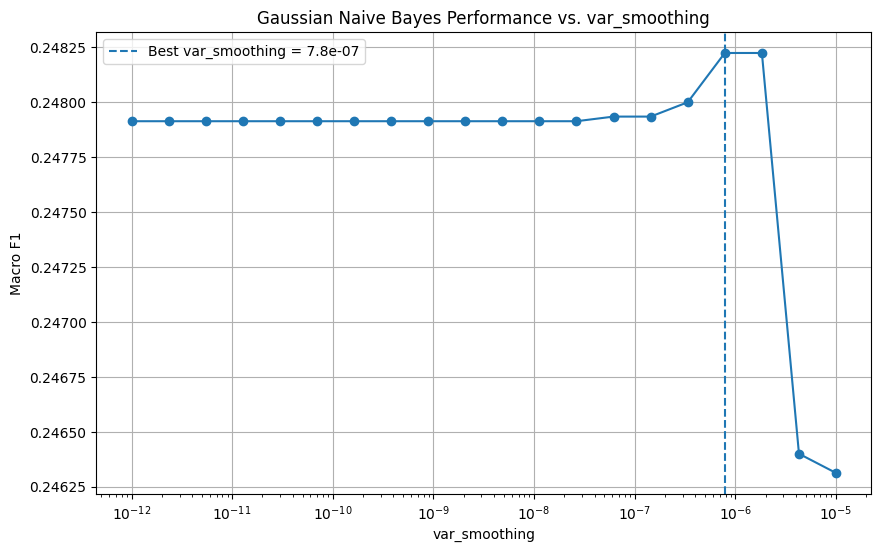

Best var_smoothing: 7.8e-07
Best Macro F1: 0.2482


In [9]:
var_values = np.logspace(-12, -5, 20)
f1_scores = []

for var in var_values:
    classifier = GaussianNB(var_smoothing=var)
    classifier.fit(X_train_scaled, y_train)

    y_pred = classifier.predict(X_test_scaled)

    f1_scores.append(
        f1_score(y_test, y_pred, average="macro", zero_division=0)
    )

best_var = var_values[f1_scores.index(max(f1_scores))]
best_f1 = max(f1_scores)

plt.figure(figsize=(10, 6))
plt.semilogx(var_values, f1_scores, marker="o")
plt.axvline(best_var, linestyle="--", label=f"Best var_smoothing = {best_var:.1e}")

plt.xlabel("var_smoothing")
plt.ylabel("Macro F1")
plt.title("Gaussian Naive Bayes Performance vs. var_smoothing")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best var_smoothing: {best_var:.1e}")
print(f"Best Macro F1: {best_f1:.4f}")

Changing the smoothing does not significantly improve performance.